# Calculate vegetation period 

This script calculates the onset, end and length of vegetation period for each pixel for one selected year using a GAM on the monthly minimum temperature.

## 0. Functions for hemisphere, date and window handling

In [46]:
# Import relevant packages
import glob
import os
import numpy as np
import rasterio
from rasterio.transform import xy
from rasterio.warp import transform
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pygam import LinearGAM, s
from datetime import datetime, timedelta
import time
from tqdm import tqdm
from joblib import Parallel, delayed
from rasterio.windows import Window
from pyproj import Transformer

create_hemisphere_masks() creates masks to differentiate the northern and southern hemisphere. This is relevant because in the south the vegetation period is in the "winter" months instead of "summer" months. That means the calculation for the north should be based on months Jan - Dec (1-12), for the south it should be based on July - June next year (7-6).

I created a small overlap of the masks at the equator because otherwise there is the issue that there are two rows of pixels with nodata values. Now a latitude below 0.1 is treated with the southern hemisphere calculation. It does not really matter at the equator bc the vegetation period is the whole year no matter the calculation.

In [47]:
def create_hemisphere_masks(src):
    """
    Create northern and southern hemisphere masks
    with the same shape as the raster grid.

    Parameters
    ----------
    src : rasterio dataset
        Open rasterio dataset defining the raster grid.

    Returns
    -------
    north_mask : np.ndarray
        Boolean array with shape (height, width).
    south_mask : np.ndarray
        Boolean array with shape (height, width).
    """

    height = src.height
    width = src.width

    # Pixel row/column indices
    rows, cols = np.indices(
        (height, width)
    )

    # Pixel centre coordinates in raster CRS
    xs, ys = xy(
        src.transform,
        rows,
        cols
    )

    # Ensure arrays have raster shape
    xs = np.asarray(xs).reshape(height, width)
    ys = np.asarray(ys).reshape(height, width)

    # Transform MODIS sinusoidal -> WGS84
    transformer = Transformer.from_crs(
        src.crs,
        "EPSG:4326",
        always_xy=True
    )

    _, lat = transformer.transform(
        xs,
        ys
    )

    lat = np.asarray(lat).reshape(height, width)

    # Hemisphere masks
    north_mask = lat >= 0
    south_mask = lat <= 0.1 # a small overlap solves the nodata issue at equator

    return north_mask, south_mask

get_vegetation_calendar() calculates the day of year for the middle day of each month in the vegetation period as input for gam training, the days (1-358/366) as input in gam prediction, and the start_date of the vegetation period. For the northern hemisphere it is calculated based on months Jan - Dec (1-12), for the south it is for months July - June next year (7-6). The result is a continuously increasing doy relative to the vegetation period and days for both hemispheres, so gam fitting works with both. The start date is the 1st Jan or the 1st July, respectively. 

In [48]:
def get_vegetation_calendar(hemisphere, year):
    """
    Create the temporal structure for a vegetation year.

    A vegetation year is defined differently depending on hemisphere:
    - Northern hemisphere: January to December of the given year.
    - Southern hemisphere: July of the given year to June of the following year.

    The function returns:
    - the observation dates (middle of each month) expressed as days
      since the start of the vegetation year,
    - all daily time steps within the vegetation year,
    - the start date of the vegetation year.

    Parameters
    ----------
    hemisphere : str
        Hemisphere identifier. Expected values:
        "north" or "south".

    year : int
        Starting year of the vegetation year.
        For the southern hemisphere, this is the year in which
        the vegetation year starts (July).

    Returns
    -------
    doy : numpy.ndarray
        Day offsets of the monthly observations (15th of each month),
        relative to the first day of the vegetation year.
        Length = 12.

    days : numpy.ndarray
        Daily time steps from the start to the end of the vegetation year.
        Used for GAM predictions.

    start_date : datetime.datetime
        First day of the vegetation year.
    """

    # Define the 12-month vegetation year depending on hemisphere
    if hemisphere == "north":

        # Northern vegetation year: January-December
        months = list(range(1, 13))
        years = [year] * 12

    else:
        # Southern vegetation year: July-June
        # The second half belongs to the following calendar year
        months = list(range(7, 13)) + list(range(1, 7))
        years = [year] * 6 + [year + 1] * 6


    # The vegetation year always starts on the first day
    # of the first month (1 January or 1 July)
    start_date = datetime(
        years[0],
        months[0],
        1
    )


    # Calculate the relative day of year for each monthly temperature value.
    # The GAM is fitted to the middle of each month (15th).
    # These are not calendar DOYs, but days since vegetation-year start.
    mid_month_doy = []

    for y, m in zip(years, months):

        mid_month_date = datetime(y, m, 15)

        doy = (
            mid_month_date - start_date
        ).days + 1

        mid_month_doy.append(doy)


    doy = np.array(mid_month_doy)


    # Determine the last day of the vegetation year.
    # This handles year transitions and leap years correctly.
    next_month = datetime(
        years[-1] + (months[-1] == 12),
        months[-1] % 12 + 1,
        1
    )

    end_date = next_month - timedelta(days=1)

    # Create daily prediction dates for the GAM.
    # The GAM predicts temperatures for every day of the vegetation year.
    n_days = (
        end_date - start_date
    ).days + 1

    days = np.arange(1, n_days + 1)


    return doy, days, start_date

generate_windows() creates windows that the raster can be divided into and that can be processed after each other.

In [49]:
def generate_windows(height, width, block_size=1000):
    """
    Yield raster windows of size block_size × block_size.
    """

    for row in range(0, height, block_size):
        for col in range(0, width, block_size):

            yield Window(
                col_off=col,
                row_off=row,
                width=min(block_size, width - col),
                height=min(block_size, height - row)
            )

## 1. Function for temperature extraction

For each middle day of month we assume the minimum temperature is the minimum monthly temperature. read_temperature_block() extracts the minimum monthly temperatures within a given window/block in degrees celsius from the rasters and stores them in a tensor of shape (12, 100, 100), i.e. (months, x, y). 

Nodata pixels (from rangeland masking) will kept as nodata in the temperatures array, and pixels in the opposite than the currently processed hemisphere get a nodata value. E.g. while processing the northern hemisphere, southern pixels just get nodata values for their temperature and vegetation period and will then be filled up when the southern hemisphere is processed with the correct southern hemisphere based dates.

The function works for both hemispheres and for leap years.

In [50]:
def read_temperature_block(
    datasets,
    window,
    hemisphere_mask, # TEST RUN: comment out
    scale_factor=0.1,
    nodata=-9999
):
    """
    Read one raster block and apply hemisphere mask.

    Parameters
    ----------
    datasets : list
        Open rasterio datasets for the vegetation year.
    window : rasterio.windows.Window
        Raster window to read.
    hemisphere_mask : np.ndarray
        Full-size boolean mask for the hemisphere.
    scale_factor : float
        Climate data scaling factor.
    nodata : int
        NoData value in input rasters.

    Returns
    -------
    tmmns : np.ndarray
        Temperature cube (months, rows, cols)
    """

    tmmns = []

    # Extract mask corresponding to this window # TEST RUN: comment out
    block_mask = hemisphere_mask[
        int(window.row_off):int(window.row_off + window.height),
        int(window.col_off):int(window.col_off + window.width)
    ]
    
    for ds in datasets:

        # Find tmmn band
        band_names = list(ds.descriptions)
        tmmn_band = band_names.index("tmmn") + 1

        # Read temperatures in block
        arr = ds.read(
            tmmn_band,
            window=window
        ).astype(np.float32)
        
        # Apply nodata mask
        arr[arr == nodata] = np.nan

        # Apply hemisphere mask
        arr[~block_mask] = np.nan # TEST RUN: comment out

        # Apply scale to get temperatures in degrees celsius 
        # (bc modis temps are stored with a scale of 0.1)
        arr *= scale_factor

        tmmns.append(arr)

    return np.stack(tmmns)

## 2. Functions for GAM fitting/vegetation period extraction and parallel processing

Now we train a GAM on the minimum temperature for the middle day of each month. Based on this we can predict the minimum temperature for all days in the vegetation period. We extract vegetation onset and end when the predicted minimum daily temperature crosses 5 degrees. It works for southern, northern hemisphere bc the gam is handed the hemisphere-specific doys and days. It also works for the equator, i.e. also correctly detects whole year or no vegetation period. In case of no vegetation period, onset and end are nodata, length is 0.

In [51]:
def fit_vegetation_period(
    pixel_temp,
    doy,
    days,
    threshold=5,
    n_splines=4,
    spline_order=3
):
    """
    Fit GAM for one pixel and calculate vegetation period.

    Parameters
    ----------
    pixel_temp : array-like
        Monthly temperature values for one pixel (length 12).
    doy : array-like
        Vegetation-year day of year for observations.
    days : array-like
        Daily prediction days.
    threshold : float
        Temperature threshold for vegetation period.
    n_splines : int
        Number of GAM splines.
    spline_order : int
        Spline order.

    Returns
    -------
    onset : float
        Vegetation onset day.
    end : float
        Vegetation end day.
    length : float
        Vegetation period length.
    """

    # Skip masked pixels
    if np.isnan(pixel_temp).any():
        return np.nan, np.nan, np.nan

    # Fit GAM
    gam = LinearGAM(
        s(
            0,
            n_splines=n_splines,
            spline_order=spline_order,
            basis="cp"
        )
    )

    gam.fit(
        doy[:, None],
        pixel_temp
    )

    # Predict daily temperatures
    pred = gam.predict(days[:, None])

    # Threshold crossing
    above = pred >= threshold

    # No vegetation period
    if not np.any(above):
        return np.nan, np.nan, 0

    # Vegetation period
    onset = days[np.argmax(above)]
    end = days[len(days) - np.argmax(above[::-1]) - 1]

    length = end - onset + 1

    return onset, end, length

process_block_parallel() applies parallel processing with a specified number of cpus for fitting the gams for each pixel. 

In [52]:
def process_block_parallel(
    tmmns,
    doy,
    days,
    threshold=5,
    n_jobs=2
):
    """
    Process one raster block using parallel GAM fitting.

    Parameters
    ----------
    tmmns : np.ndarray
        Temperature cube (months, rows, cols)
    doy : np.ndarray
        Observation days of vegetation year
    days : np.ndarray
        Daily prediction days
    threshold : float
        Temperature threshold
    n_jobs : int
        Number of parallel workers (-1 = all cores)

    Returns
    -------
    onset_map, end_map, length_map
    """

    n_rows = tmmns.shape[1]
    n_cols = tmmns.shape[2]

    # Create list of pixels
    pixels = [
        tmmns[:, row, col]
        for row in range(n_rows)
        for col in range(n_cols)
    ]

    # Fit GAMs in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_vegetation_period)(
            pixel,
            doy,
            days,
            threshold
        )
        for pixel in pixels
    )

    # Convert results back to arrays
    results = np.array(results)

    onset_map = results[:, 0].reshape(n_rows, n_cols)
    end_map = results[:, 1].reshape(n_rows, n_cols)
    length_map = results[:, 2].reshape(n_rows, n_cols)

    return onset_map, end_map, length_map

## 3. Main

In [59]:
# --------------------------------------------------
# Input data and vegetation year definition
# --------------------------------------------------

# Folder containing monthly climate GeoTIFFs.
# Each file contains one month with minimum and maximum temperature bands.
path = "/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly"

# Starting year of the vegetation year.
# For the southern hemisphere, the vegetation year spans into year+1.
year = 2024


# --------------------------------------------------
# Create ordered monthly file lists
# --------------------------------------------------

# Northern hemisphere vegetation year:
# January -> December of the same calendar year.
months_north = list(range(1, 13))
years_north = [year] * 12

files_northern = []

for y, m in zip(years_north, months_north):

    files_northern.append(
        os.path.join(
            path,
            f"Climate_monthly_{y}-{m:02d}-01.tif"
        )
    )


# Southern hemisphere vegetation year:
# July -> June, because the growing season crosses
# the calendar year boundary.
months_south = list(range(7, 13)) + list(range(1, 7))
years_south = [year] * 6 + [year + 1] * 6

files_southern = []

for y, m in zip(years_south, months_south):

    files_southern.append(
        os.path.join(
            path,
            f"Climate_monthly_{y}-{m:02d}-01.tif"
        )
    )


print("Northern:")
print(files_northern)

print("\nSouthern:")
print(files_southern)

Northern:
['/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-01-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-02-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-03-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-04-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-05-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-06-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-07-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-08-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-09-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2024-10-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_mo

In [60]:
# --------------------------------------------------
# Start timer
# --------------------------------------------------

start_time = time.time()


# --------------------------------------------------
# Open reference raster and create hemisphere masks
# --------------------------------------------------

# The processing grid is defined by the input MODIS sinusoidal raster.
# Hemisphere masks ensure that pixels are processed using the correct
# vegetation year definition (Jan-Dec in the north, Jul-Jun in the south).
with rasterio.open(files_northern[0]) as src:

    height = src.height
    width = src.width

    profile = src.profile.copy()


    # Create hemisphere masks
    north_mask, south_mask = create_hemisphere_masks(src)


# --------------------------------------------------
# Create output raster
# --------------------------------------------------

# The output contains three vegetation period metrics:
# 1. onset  - first day exceeding the temperature threshold
# 2. end    - last day exceeding the temperature threshold
# 3. length - duration of the vegetation period in days
profile.update(
    count=3,
    dtype="float32",
    nodata=np.nan,
    compress="deflate"
)

output_path = f"vegetation_period_{year}.tif"


with rasterio.open(output_path, "w", **profile) as dst:

    dst.set_band_description(1, "vegetation_onset")
    dst.set_band_description(2, "vegetation_end")
    dst.set_band_description(3, "vegetation_length")


    # --------------------------------------------------
    # Process northern and southern hemispheres separately
    # --------------------------------------------------

    # The two hemispheres require different temporal ordering of the
    # monthly climate data. Processing them separately prevents blocks
    # from containing pixels with incompatible vegetation calendars.
    for hemisphere, hemisphere_mask in [
        ("north", north_mask),
        ("south", south_mask)
    ]:

        print(f"\nProcessing {hemisphere} hemisphere")


        # Create correct temporal reference for vegetation year:
        # - monthly observation dates for GAM fitting
        # - daily prediction dates for vegetation period detection
        doy, days, start_date = get_vegetation_calendar(
            hemisphere,
            year
        )


        # Select the corresponding monthly climate sequence.
        if hemisphere == "north":

            files = files_northern

        else:

            files = files_southern


        # Open all monthly rasters of the vegetation year.
        datasets = [
            rasterio.open(f)
            for f in files
        ]


        try:

            # Process the global raster in spatial blocks to keep
            # memory usage manageable.
            block_size = 1000

            n_blocks = (
                int(np.ceil(height / block_size)) *
                int(np.ceil(width / block_size))
            )


            for window in tqdm(
                generate_windows(
                    height,
                    width,
                    block_size=block_size
                ),
                total=n_blocks,
                desc=f"{hemisphere} blocks"
            ):


                # Read the minimum temperatures in one spatial block for all 12 months.
                # The function applies:
                # - NoData masking
                # - hemisphere masking
                # - temperature scaling
                tmmns = read_temperature_block(
                    datasets,
                    window,
                    hemisphere_mask
                )


                # Ignore blocks without valid climate observations
                # (e.g. ocean or pixels outside the hemisphere).
                if np.isnan(tmmns).all():
                    continue


                # Fit a GAM independently for every valid pixel.
                # The fitted temperature curve is then used to identify
                # when the threshold temperature is crossed.
                onset_map, end_map, length_map = process_block_parallel(
                    tmmns,
                    doy,
                    days,
                    threshold=5,
                    n_jobs=8
                )


                # Write the vegetation period metrics back into the
                # corresponding spatial window of the output raster.
                dst.write(
                    onset_map.astype("float32"),
                    1,
                    window=window
                )

                dst.write(
                    end_map.astype("float32"),
                    2,
                    window=window
                )

                dst.write(
                    length_map.astype("float32"),
                    3,
                    window=window
                )


        finally:

            # Close all monthly climate rasters after processing
            # to avoid keeping many files open simultaneously.
            for ds in datasets:
                ds.close()


# --------------------------------------------------
# Runtime summary
# --------------------------------------------------

runtime = time.time() - start_time

print("\nFinished processing")
print(f"Saved: {output_path}")
print(
    f"Total runtime: {runtime/3600:.2f} hours "
    f"({runtime/60:.1f} minutes)"
)


Processing north hemisphere


north blocks:   0%|          | 0/45 [00:00<?, ?it/s]/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_59921/1898461801.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = ds.read(
north blocks: 100%|██████████| 45/45 [14:19<00:00, 19.10s/it] 



Processing south hemisphere


RasterioIOError: /Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2025-01-01.tif: No such file or directory

## 4. Maps

In [ ]:
# --------------------------------------------------------------------------
# Read matching elevation window to compare the vegetation period output to
# --------------------------------------------------------------------------

elevation_path = '/Volumes/TOSHIBA EXT/non-equilibrium/data/elevation/Elevation_resampled_masked_2010-01-01.tif'

with rasterio.open(elevation_path) as src:
    elevation = src.read(
        1,
        #window=(
        #    (row_min, row_max),
        #   (col_min, col_max)
        #)
    )

# Mask no-data values
elevation = np.where(elevation == -9999, np.nan, elevation)

/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_47701/1658336789.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  elevation = src.read(


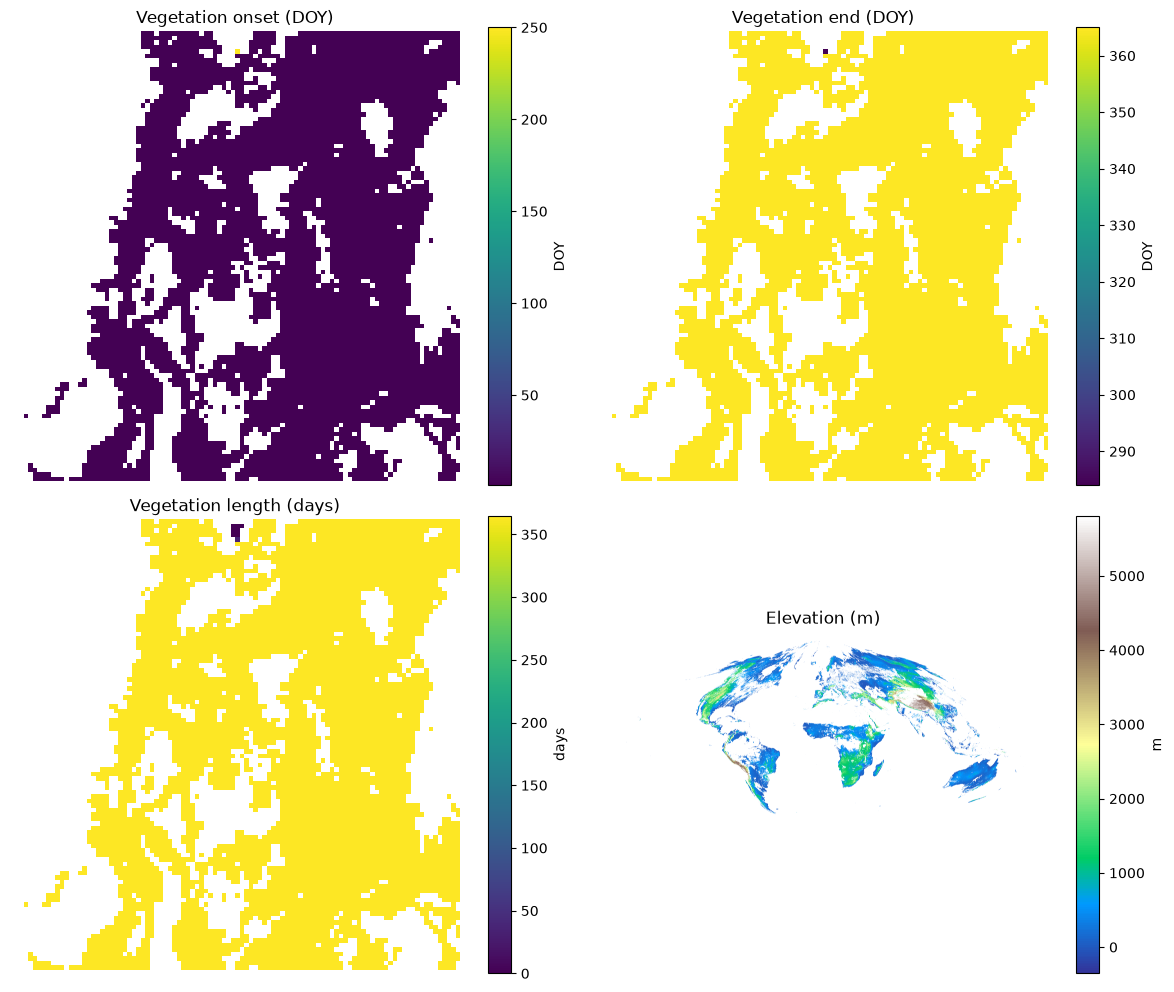

In [34]:
# --------------------------------------------------
# Plot elevation + vegetation period maps
# --------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

im0 = axes[0, 0].imshow(
    onset_map,
    cmap="viridis"
)
axes[0, 0].set_title("Vegetation onset (DOY)")
plt.colorbar(im0, ax=axes[0, 0], label="DOY")


im1 = axes[0, 1].imshow(
    end_map,
    cmap="viridis"
)
axes[0, 1].set_title("Vegetation end (DOY)")
plt.colorbar(im1, ax=axes[0, 1], label="DOY")


im2 = axes[1, 0].imshow(
    length_map,
    cmap="viridis"
)
axes[1, 0].set_title("Vegetation length (days)")
plt.colorbar(im2, ax=axes[1, 0], label="days")


im3 = axes[1, 1].imshow(
    elevation,
    cmap="terrain"
)
axes[1, 1].set_title("Elevation (m)")
plt.colorbar(im3, ax=axes[1, 1], label="m")


for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Test some functions on example window

In [19]:
# TODO: Select desired year and location

# Year
year = 2001

# Desired location (WGS84)
lon = 29.9 # near equator 29.9  # south africa 24 # altai 88.0 # europe 10.0 
lat = -1.8 # near equator -1.8 # south africa -27 # altai 49.0 # europe 50.0

### Define temporal extent

In [20]:
path = "/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly"

# Define months depending on hemisphere
if lat >= 0:
    months = list(range(1, 13))
    years = [year] * 12

else:
    months = list(range(7, 13)) + list(range(1, 7))
    years = [year] * 6 + [year + 1] * 6

print(months)
print(years)

# Create ordered file list
files_vegetation_year = []

for y, m in zip(years, months):
    pattern = os.path.join(
        path,
        f"Climate_monthly_{y}-{m:02d}-01.tif"
    )
    files_vegetation_year.append(pattern)

print(files_vegetation_year)

[7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]
[2001, 2001, 2001, 2001, 2001, 2001, 2002, 2002, 2002, 2002, 2002, 2002]
['/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-07-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-08-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-09-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-10-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-11-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2001-12-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-01-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-02-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly/Climate_monthly_2002-03-01.tif', '/Volumes/TOSHIBA EXT/non-equilibrium/data/climate_monthly

### Define spatial extent

In [21]:
with rasterio.open(files_vegetation_year[0]) as src:

    # Convert lat/lon to raster CRS
    x, y = transform(
        "EPSG:4326",
        src.crs,
        [lon],
        [lat]
    )

    # Convert coordinates to pixel indices
    target_row, target_col = rowcol(
        src.transform,
        x[0],
        y[0]
    )

    # Create valid pixel mask
    band_names = list(src.descriptions)
    tmmn_band = band_names.index("tmmn") + 1

    tmmn = src.read(tmmn_band)
    valid_mask = tmmn != -9999

# Search radius around target pixel
radius = 10

candidates = []

for r in range(
    max(0, target_row - radius),
    min(valid_mask.shape[0], target_row + radius + 1)
):
    for c in range(
        max(0, target_col - radius),
        min(valid_mask.shape[1], target_col + radius + 1)
    ):
        if valid_mask[r, c]:
            distance = (r - target_row)**2 + (c - target_col)**2
            candidates.append((distance, r, c))

# Select nearest valid pixel
_, row, col = min(candidates)

print(f"Selected pixel: row={row}, col={col}")

Selected pixel: row=2041, col=4669


/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_48472/1372104437.py:22: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  tmmn = src.read(tmmn_band)


In [22]:
window_size = 100
half = window_size // 2

row_min = max(0, target_row - half)
row_max = min(valid_mask.shape[0], target_row + half)

col_min = max(0, target_col - half)
col_max = min(valid_mask.shape[1], target_col + half)

print(f"Window: row={row_min}:{row_max}, col={col_min}:{col_max}")

window = Window(
    col_off=col_min,
    row_off=row_min,
    width=col_max - col_min,
    height=row_max - row_min
)

print(window)

Window: row=1991:2091, col=4619:4719
Window(col_off=np.int32(4619), row_off=np.int32(1991), width=np.int32(100), height=np.int32(100))


In [23]:
# Start date of the vegetation year (always the first day)
start_date = datetime(years[0], months[0], 1)

# Middle day of each month in the vegetation year
mid_month_doy = []

for y, m in zip(years, months):
    mid_month_date = datetime(y, m, 15)
    doy = (mid_month_date - start_date).days + 1
    mid_month_doy.append(doy)

doy = np.array(mid_month_doy)
print(doy)

[ 15  46  77 107 138 168 199 230 258 289 319 350]


In [24]:
# --------------------------------------------------
# Predict days of year
# --------------------------------------------------

start_date = datetime(years[0], months[0], 1)
# End of vegetation year (last day of last month)
next_month = datetime(
    years[-1] + (months[-1] == 12),
    months[-1] % 12 + 1,
    1
)
end_date = next_month - timedelta(days=1)

n_days = (end_date - start_date).days + 1

days = np.arange(1, n_days + 1)

### Test read_temperature_block() and process_block_parallel()

For this to work you have to uncomment the hemisphere mask in the read_temperature_block() function.

In [32]:
datasets = [rasterio.open(f) for f in files_vegetation_year]

try:
    # Read one block
    tmmns = read_temperature_block(
        datasets,
        window
    )

    print(tmmns.shape)      # (12, 100, 100)

    # Fit GAMs
    onset_map, end_map, length_map = process_block_parallel(
        tmmns,
        doy,
        days,
        threshold=5
    )

finally:
    for ds in datasets:
        ds.close()

/var/folders/v8/1_2rlmrd0wl5w5t5n60h8s440000gn/T/ipykernel_47701/988377851.py:46: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = ds.read(


(12, 100, 100)


### Test create_hemisphere_masks()

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [False False False ... False False False]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


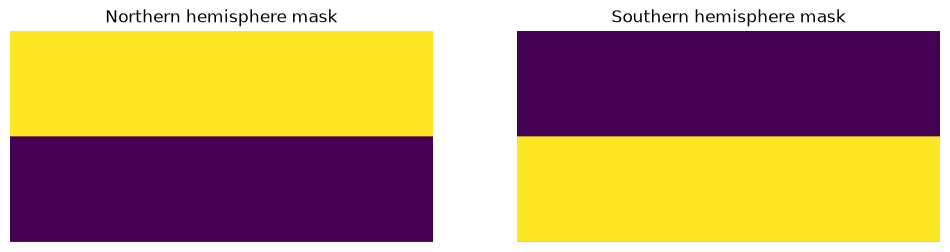

In [25]:
with rasterio.open(files_vegetation_year[0]) as src:

    height = src.height
    width = src.width

    north_mask, south_mask = create_hemisphere_masks(src)

print(north_mask)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(north_mask)
plt.title("Northern hemisphere mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(south_mask)
plt.title("Southern hemisphere mask")
plt.axis("off")

plt.show()

### Test generate_windows()

In [23]:
datasets = [rasterio.open(f) for f in files_vegetation_year]

height = datasets[0].height
width = datasets[0].width

for window in generate_windows(height, width, block_size=1000):
    print(window)

Window(col_off=0, row_off=0, width=1000, height=1000)
Window(col_off=1000, row_off=0, width=1000, height=1000)
Window(col_off=2000, row_off=0, width=1000, height=1000)
Window(col_off=3000, row_off=0, width=1000, height=1000)
Window(col_off=4000, row_off=0, width=1000, height=1000)
Window(col_off=5000, row_off=0, width=1000, height=1000)
Window(col_off=6000, row_off=0, width=1000, height=1000)
Window(col_off=7000, row_off=0, width=1000, height=1000)
Window(col_off=8000, row_off=0, width=8, height=1000)
Window(col_off=0, row_off=1000, width=1000, height=1000)
Window(col_off=1000, row_off=1000, width=1000, height=1000)
Window(col_off=2000, row_off=1000, width=1000, height=1000)
Window(col_off=3000, row_off=1000, width=1000, height=1000)
Window(col_off=4000, row_off=1000, width=1000, height=1000)
Window(col_off=5000, row_off=1000, width=1000, height=1000)
Window(col_off=6000, row_off=1000, width=1000, height=1000)
Window(col_off=7000, row_off=1000, width=1000, height=1000)
Window(col_off=8

### Test get_vegetation_calendar()

In [24]:
doy_north, days_north, start_north = get_vegetation_calendar(
    "north",
    2001
)

doy_south, days_south, start_south = get_vegetation_calendar(
    "south",
    2001
)

print(doy_north, start_north)
print(doy_south, start_south)

[ 15  46  74 105 135 166 196 227 258 288 319 349] 2001-01-01 00:00:00
[ 15  46  77 107 138 168 199 230 258 289 319 350] 2001-07-01 00:00:00


## Questions for Henrik:
- remember: currently we just take the first and the last crossing of 8 degrees, so assume 1 veg period
- we have only min and max monthly temperature: do we "average" it first, then fit the gam, or fit the gam for max and min separately and then average on the day? and can we really assume that the min and max temperature both happen in the middle of the month?
    - minimale temperatur, wir nehmen an sie passiert in der mitte vom monat, und 5 grad als threshold für onset und end
- how to specify the gam? how many splines etc?
    - eine polynomial funktion kann man auch mal ausprobieren
- what do we do about the southern hempishpere where the vegetation period might cross the year boundary? 
    - fitting one gam for all 25 years combined? or a moving window?
    - für südhalbkugel monate 6-18 nehmen
- Recommmended next step: Karte für alle pixel für 1 jahr, 100 mal 100 ausprobieren, am besten altai in zentralasien

2 prios: dass es zeitnah fertig wird und dass ich was lerne 

## New questions for Henrik:
- which distribution do we assume for minimum temperature? to specify the distribution in the gam correctly
- do we need proper validation for number and order of splines?
- can i use your mac? do i need to install python and everything?

## To do:
1. take minimum temperature, assume it happens in the middle of the month, take 5 degrees as threshold for onset and end - DONE
2. try a gam with polynomial function, different splines - DONE
   - 3 splines order 2, or 4 splines order 3 seem good; I assume temperatures to be normally distributed, therefore linearGAM
3. adapt code to be flexible with leap years (tested with 2004 and it works) - DONE
    - should work now, but check again with actual leap year data, e.g. 2004
4. extend spatially: write code to try it on an example region of 100x100 pixels in a mountaineous region in central asia like the altai - DONE
5. make a map that shows the vegetation period for the pixels in the example region - DONE
6. extend temporally: write code to take months 1-12 for north of globe and 6-18 for south of globe (bc in southern hemisphere the veg period crosses the year boundary; equator doesn't matter because it's always above 5 degrees anyways); check if it works as well for equator when the vegetation period is the whole year - DONE
7. extend spatially: write code for global -> try parallel processing or chunks? - DONE 
8. save the vegetation period information in a modis raster (or table?) iteratively - DONE
9. clean code, look at the half done saved raster, comment code - DONE
10. test run on whole world and compare with little example code if it leads to same result - DONE